<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Define the column names
column_names = ['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality', 'Load','Machine Type','Failure Type','Component Type']

# Generate random data for each column
num_rows = 100
data = {
    'Temperature': np.random.uniform(20, 100, num_rows),  # Temperature between 20 and 100
    'Vibration': np.random.uniform(0, 1, num_rows),  # Vibration between 0 and 1
    'Pressure': np.random.uniform(1, 10, num_rows),  # Pressure between 1 and 10
    'Humidity': np.random.uniform(30, 80, num_rows),  # Humidity between 30 and 80
    'RPM': np.random.uniform(1000, 5000, num_rows),  # RPM between 1000 and 5000
    'Voltage': np.random.uniform(110, 240, num_rows),  # Voltage between 110 and 240
    'Current': np.random.uniform(1, 10, num_rows),  # Current between 1 and 10
    'Sound_Level': np.random.uniform(60, 100, num_rows),  # Sound level between 60 and 100
    'Oil_Quality': np.random.uniform(0, 1, num_rows),  # Oil quality between 0 and 1
    'Load': np.random.uniform(0, 100, num_rows),  # Load between 0 and 100
    'Machine Type': np.random.choice(['Pump', 'Motor', 'Compressor', 'Turbine'], num_rows),  # Randomly assigns one of the four machine types to each row
    'Failure Type': np.random.choice(['Overheating', 'Vibration, Wear', 'Electrical', 'No Failure'], num_rows),  # Randomly assigns one of the four failure types to each row
    'Component Type': np.random.choice(['Bearing', 'Gear', 'Seal', 'Fan Blade'], num_rows)  # Randomly assigns one of the four component types to each row
}

# Combine columns to the data to create the dataset
pred = pd.DataFrame(data, columns=column_names)



In [3]:
pred.head()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
0,58.192868,0.823341,2.457322,46.134374,2183.760104,229.067663,1.047746,90.220743,0.855646,11.880303,Compressor,Overheating,Gear
1,93.349888,0.446852,9.109342,72.462881,1094.174215,163.013324,3.285095,91.034408,0.403910,50.640979,Turbine,"Vibration, Wear",Seal
2,83.821993,0.866552,9.709840,72.545376,2101.599415,166.498640,9.977748,81.512929,0.065536,79.796432,Pump,"Vibration, Wear",Fan Blade
3,95.833449,0.885977,4.276358,41.089480,3700.831539,144.480602,9.727183,72.518710,0.371565,82.146236,Turbine,Overheating,Gear
4,52.377089,0.288191,7.347659,64.159437,1383.605595,156.904942,3.537555,99.155988,0.974831,99.224896,Compressor,No Failure,Fan Blade


In [4]:
pred.tail()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
95,60.600880,0.441121,9.918069,60.112323,2476.679699,224.025453,4.917409,89.038111,0.887697,83.480723,Turbine,No Failure,Gear
96,47.192946,0.499556,4.049466,71.158631,4214.184043,178.987395,1.301005,72.175291,0.259930,64.592416,Pump,Overheating,Seal
97,92.862447,0.966439,6.369174,36.955992,2551.217268,226.380231,4.434937,78.414220,0.956055,59.509133,Turbine,Electrical,Gear
98,84.752886,0.271993,1.308783,68.345435,1349.316602,140.438867,1.923348,62.524530,0.608300,88.364797,Turbine,No Failure,Fan Blade
99,33.992226,0.440275,5.898494,74.464964,1030.428762,162.064972,8.518635,81.616226,0.433573,29.829910,Turbine,Overheating,Fan Blade


# **Exploratory Data Analysis**

In [5]:
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     100 non-null    float64
 1   Vibration       100 non-null    float64
 2   Pressure        100 non-null    float64
 3   Humidity        100 non-null    float64
 4   RPM             100 non-null    float64
 5   Voltage         100 non-null    float64
 6   Current         100 non-null    float64
 7   Sound_Level     100 non-null    float64
 8   Oil_Quality     100 non-null    float64
 9   Load            100 non-null    float64
 10  Machine Type    100 non-null    object 
 11  Failure Type    100 non-null    object 
 12  Component Type  100 non-null    object 
dtypes: float64(10), object(3)
memory usage: 10.3+ KB


In [6]:
pred.describe()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,58.294263,0.489566,5.792265,53.311582,2919.564922,167.747588,5.465439,79.536752,0.485031,54.275682
std,23.763129,0.264550,2.594791,14.753636,1157.712133,35.043985,2.724670,11.503954,0.320873,30.662329
min,20.061687,0.013759,1.308783,30.574430,1030.428762,110.987640,1.047746,60.097302,0.001426,0.458614
25%,39.710970,0.304023,3.707111,40.980420,1952.818359,139.858244,3.166366,70.824156,0.164142,26.345337
50%,53.996221,0.451097,5.626651,52.623331,2814.240002,162.141801,5.202678,80.504298,0.468967,58.990725
75%,77.612901,0.708513,7.790951,66.119885,3944.807658,198.667952,7.808520,89.530717,0.797960,79.809487
max,99.354142,0.986596,9.968284,79.532722,4980.932195,237.524492,9.977748,99.600480,0.974831,99.763035


             Temperature  Vibration  Pressure  Humidity       RPM   Voltage  \
Temperature     1.000000   0.145300 -0.092427  0.128682 -0.187173  0.009819   
Vibration       0.145300   1.000000  0.071877 -0.040122  0.103911  0.081107   
Pressure       -0.092427   0.071877  1.000000  0.079489 -0.038659  0.001847   
Humidity        0.128682  -0.040122  0.079489  1.000000 -0.076955 -0.220140   
RPM            -0.187173   0.103911 -0.038659 -0.076955  1.000000 -0.129116   
Voltage         0.009819   0.081107  0.001847 -0.220140 -0.129116  1.000000   
Current        -0.095480   0.001580 -0.080502  0.098235  0.016058 -0.115451   
Sound_Level     0.049983  -0.128141 -0.009103 -0.029499 -0.099982  0.090109   
Oil_Quality     0.019941  -0.067631  0.162668 -0.087942 -0.050556 -0.111132   
Load            0.151495  -0.001106 -0.062540  0.154046 -0.010833  0.075187   

              Current  Sound_Level  Oil_Quality      Load  
Temperature -0.095480     0.049983     0.019941  0.151495  
Vibration 

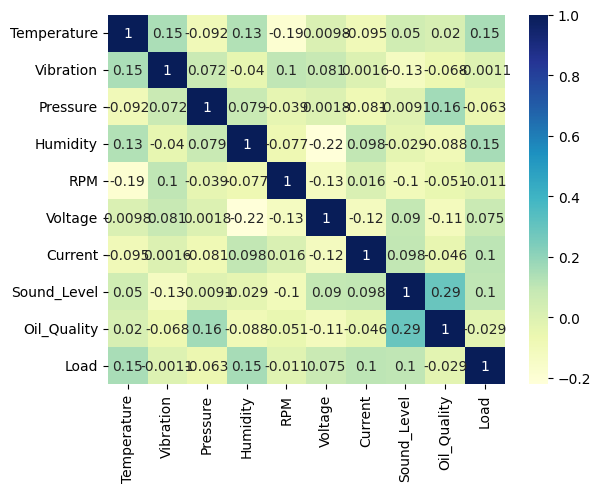

In [7]:
co_mtx = pred.corr(numeric_only=True)

print(co_mtx)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

# **Random Forest**

In [8]:
for col in pred:
  if pred[col].dtype == 'O':
    codes, _ = pd.factorize(pred[col])
    pred[col] = codes

In [9]:
X = pred[['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality','Load',
          'Failure Type','Component Type','Machine Type']]
y = pred['Component Type']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)